In [ ]:
import zipfile
import pandas as pd

# ZIP 압축 풀기
with zipfile.ZipFile('archive (1).zip', 'r') as z:
    z.extractall()

# 엑셀 파일 읽기
df = pd.read_excel('ppc_campaign_performance_data.xlsx')

print(df.shape)
print(df.columns.tolist())
df.head()

(1000, 19)
['Campaign_ID', 'Budget', 'Clicks', 'CTR', 'CPC', 'Conversions', 'CPA', 'Conversion_Rate', 'Duration', 'Platform', 'Content_Type', 'Target_Age', 'Target_Gender', 'Region', 'Revenue', 'Spend', 'ROAS', 'Date', 'Impressions']


,Campaign_ID,Budget,Clicks,CTR,CPC,Conversions,CPA,Conversion_Rate,Duration,Platform,Content_Type,Target_Age,Target_Gender,Region,Revenue,Spend,ROAS,Date,Impressions
0,C3578,6390,401,0.0461,15.94,174,36.72,0.4339,20,Instagram,Carousel,35-44,Male,Europe,27840,6453.9,4.31,2025-01-19,8698
1,C6702,9870,1286,0.2860,7.67,821,12.02,0.6384,28,LinkedIn,Text,55+,Male,Africa,128076,10067.4,12.72,2025-01-22,4496
2,C9725,7700,1684,0.2122,4.57,1060,7.26,0.6295,15,Instagram,Video,35-44,Other,North America,193980,7623.0,25.45,2024-07-23,7935
3,C9472,8420,444,0.0961,18.96,308,27.34,0.6937,25,Google,Text,25-34,Male,North America,24024,8504.2,2.82,2024-04-20,4620
4,C7601,8470,1912,0.3652,4.43,1428,5.93,0.7469,9,Google,Text,25-34,Other,Europe,277032,8046.5,34.43,2024-08-07,5235


In [ ]:
# 전체 shape 확인
print("데이터 크기:", df.shape)
print("\n플랫폼 종류:")
print(df['Platform'].value_counts())
print("\n기본 통계:")
df[['CTR','CPC','CPA','Conversion_Rate']].describe().round(2)

데이터 크기: (1000, 19)

플랫폼 종류:
Platform
LinkedIn     224
Instagram    200
Facebook     198
YouTube      195
Google       183
Name: count, dtype: int64

기본 통계:


,CTR,CPC,CPA,Conversion_Rate
count,1000.00,1000.00,1000.00,1000.00
mean,0.26,11.23,40.97,0.51
std,0.26,16.03,76.62,0.28
min,0.01,1.08,1.67,0.01
25%,0.09,3.71,7.16,0.27
50%,0.18,5.76,14.24,0.52
75%,0.31,11.28,36.84,0.75
max,1.79,132.31,733.08,1.00


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False

# Google 데이터만 필터링
google_df = df[df['Platform'] == 'Google'].copy()
print("Google 캠페인 수:", len(google_df))

# ROAS 계산 (없으면 Conversion_Rate 기반 효율 지표 사용)
print("\nGoogle 캠페인 기본 통계:")
google_df[['CTR','CPC','CPA','Conversion_Rate']].describe().round(2)

Google 캠페인 수: 183

Google 캠페인 기본 통계:


,CTR,CPC,CPA,Conversion_Rate
count,183.00,183.00,183.00,183.00
mean,0.26,11.31,36.84,0.51
std,0.28,17.33,54.20,0.28
min,0.01,1.31,1.90,0.01
25%,0.09,3.54,6.91,0.29
50%,0.18,5.78,13.16,0.52
75%,0.32,10.74,40.56,0.73
max,1.72,124.93,275.00,1.00


CPA 80% 기준선: 52.93
비효율 캠페인 수: 37개
비효율 캠페인 평균 CPA: 124.84
전체 평균 CPA: 36.84


/tmp/ipykernel_2583/4199066494.py:19: UserWarning: Glyph 52896 (\N{HANGUL SYLLABLE KAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/4199066494.py:19: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/4199066494.py:19: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/4199066494.py:19: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/4199066494.py:19: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/4199066494.py:19: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/4199066494.py:19: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_lay

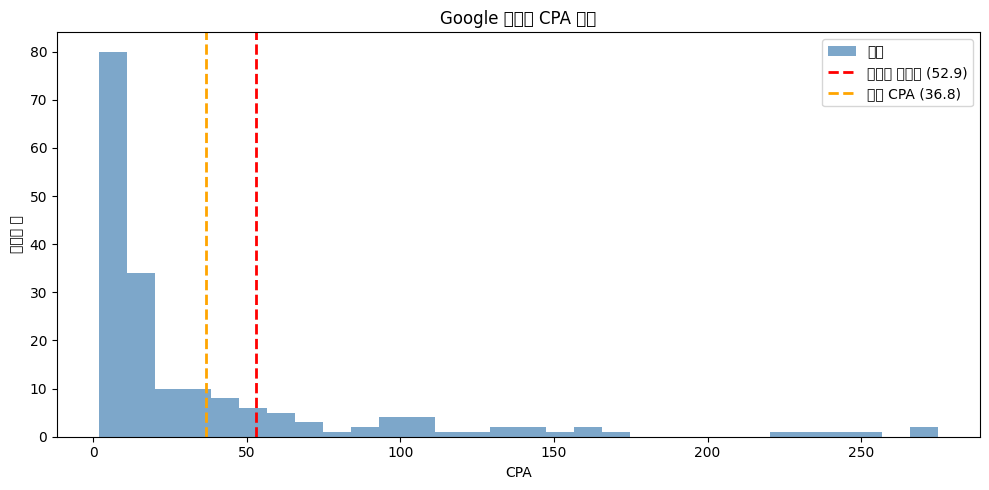

In [ ]:
# 비효율 캠페인 추출 (CPA 상위 20%)
threshold = google_df['CPA'].quantile(0.8)
high_cpa = google_df[google_df['CPA'] >= threshold].copy()

print(f"CPA 80% 기준선: {threshold:.2f}")
print(f"비효율 캠페인 수: {len(high_cpa)}개")
print(f"비효율 캠페인 평균 CPA: {high_cpa['CPA'].mean():.2f}")
print(f"전체 평균 CPA: {google_df['CPA'].mean():.2f}")

# 시각화
plt.figure(figsize=(10, 5))
plt.hist(google_df['CPA'], bins=30, color='steelblue', alpha=0.7, label='전체')
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'비효율 기준선 ({threshold:.1f})')
plt.axvline(google_df['CPA'].mean(), color='orange', linestyle='--', linewidth=2, label=f'평균 CPA ({google_df["CPA"].mean():.1f})')
plt.title('Google 캠페인 CPA 분포')
plt.xlabel('CPA')
plt.ylabel('캠페인 수')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 코랩 한글 폰트 설치
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
               capture_output=True)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 캐시 초기화
fm._load_fontmanager(try_read_cache=False)

# 나눔고딕 적용
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정 완료")

한글 폰트 설정 완료


/tmp/ipykernel_2583/1943721679.py:32: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/1943721679.py:32: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/1943721679.py:32: UserWarning: Glyph 52896 (\N{HANGUL SYLLABLE KAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/1943721679.py:32: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/1943721679.py:32: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/1943721679.py:32: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/1943721679.py:32: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_

=== 효율 캠페인 (CPA 하위 20%) ===
캠페인 수: 37개
평균 CPA: 4.23
평균 CTR: 0.4059
평균 전환율: 0.7058

=== 비효율 캠페인 (CPA 상위 20%) ===
캠페인 수: 37개
평균 CPA: 124.84
평균 CTR: 0.1196
평균 전환율: 0.2434


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

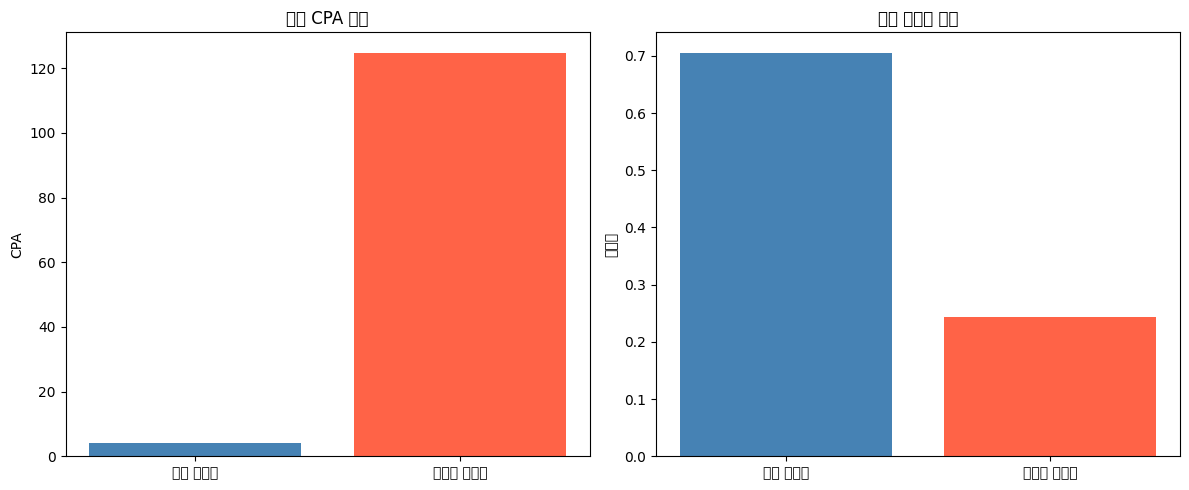

In [ ]:
# 비효율 캠페인 (CPA 상위 20%) vs 효율 캠페인 (CPA 하위 20%) 비교
low_cpa = google_df[google_df['CPA'] <= google_df['CPA'].quantile(0.2)].copy()
high_cpa = google_df[google_df['CPA'] >= google_df['CPA'].quantile(0.8)].copy()

print("=== 효율 캠페인 (CPA 하위 20%) ===")
print(f"캠페인 수: {len(low_cpa)}개")
print(f"평균 CPA: {low_cpa['CPA'].mean():.2f}")
print(f"평균 CTR: {low_cpa['CTR'].mean():.4f}")
print(f"평균 전환율: {low_cpa['Conversion_Rate'].mean():.4f}")

print("\n=== 비효율 캠페인 (CPA 상위 20%) ===")
print(f"캠페인 수: {len(high_cpa)}개")
print(f"평균 CPA: {high_cpa['CPA'].mean():.2f}")
print(f"평균 CTR: {high_cpa['CTR'].mean():.4f}")
print(f"평균 전환율: {high_cpa['Conversion_Rate'].mean():.4f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['효율 캠페인', '비효율 캠페인'],
            [low_cpa['CPA'].mean(), high_cpa['CPA'].mean()],
            color=['steelblue', 'tomato'])
axes[0].set_title('평균 CPA 비교')
axes[0].set_ylabel('CPA')

axes[1].bar(['효율 캠페인', '비효율 캠페인'],
            [low_cpa['Conversion_Rate'].mean(), high_cpa['Conversion_Rate'].mean()],
            color=['steelblue', 'tomato'])
axes[1].set_title('평균 전환율 비교')
axes[1].set_ylabel('전환율')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2583/2220401308.py:23: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/2220401308.py:23: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/2220401308.py:23: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/2220401308.py:23: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/2220401308.py:23: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/2220401308.py:23: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2583/2220401308.py:23: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_l

=== 예산 재배분 시뮬레이션 ===
전체 예산: 2,070
비효율 캠페인 낭비 예산: 1,016
낭비 예산 비율: 49.1%

이 예산을 효율 캠페인에 재배분하면
추가 전환 수: 240건


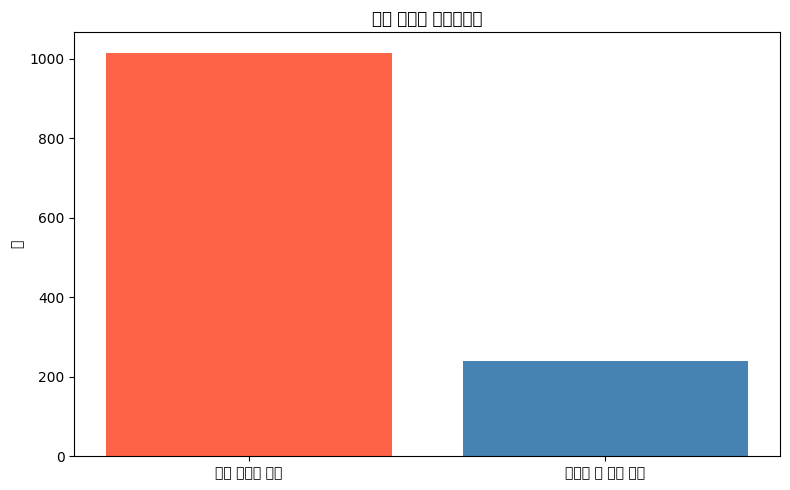

In [ ]:
# 예산 재배분 시뮬레이션
total_budget = google_df['CPC'].sum()
wasted_budget = high_cpa['CPC'].sum()
efficient_avg_cpa = low_cpa['CPA'].mean()

# 비효율 예산을 효율 캠페인으로 돌렸을 때 추가 전환 수
additional_conversions = wasted_budget / efficient_avg_cpa

print("=== 예산 재배분 시뮬레이션 ===")
print(f"전체 예산: {total_budget:,.0f}")
print(f"비효율 캠페인 낭비 예산: {wasted_budget:,.0f}")
print(f"낭비 예산 비율: {wasted_budget/total_budget*100:.1f}%")
print(f"\n이 예산을 효율 캠페인에 재배분하면")
print(f"추가 전환 수: {additional_conversions:.0f}건")

# 시각화
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['현재 비효율 예산', '재배분 시 추가 전환'],
       [wasted_budget, additional_conversions],
       color=['tomato', 'steelblue'])
ax.set_title('예산 재배분 시뮬레이션')
ax.set_ylabel('값')
plt.tight_layout()
plt.show()

In [ ]:
print(f"낭비 예산: {wasted_budget:,.0f}")
print(f"추가 전환 수: {additional_conversions:.0f}건")
print(f"낭비 예산 비율: {wasted_budget/total_budget*100:.1f}%")

낭비 예산: 1,016
추가 전환 수: 240건
낭비 예산 비율: 49.1%
